# Train Sentinel Water LoRA

Self-contained LoRA training for `stable-diffusion-v1-5/stable-diffusion-inpainting`.

This notebook reads image/mask pairs from `datasets/sentinel_water` and saves adapter weights to `notebooks/outputs/lora_sentinel_water_sd15_inpaint`.


## Configuration Notes

These values do not all mean the same thing:

- `INSTANCE_PROMPT` is the caption used during LoRA training. It teaches the adapter what concept the training masks represent.
- `VALIDATION_PROMPT` and `NEGATIVE_PROMPT` are inference-time prompts. Changing them does not retrain the LoRA.
- `VALIDATION_LORA_SCALE` controls how strongly the trained adapter is applied at inference. Higher values force the learned concept more, but can also create artifacts.
- `VALIDATION_STRENGTH` controls how much noise is applied to the masked region. Higher values replace more of the masked content; lower values preserve more of the original image.
- `VALIDATION_GUIDANCE_SCALE` controls prompt pressure. Higher values follow the text more strongly, but can make textures less natural.


## Training Methodology

This notebook trains a small LoRA adapter on top of the Stable Diffusion inpainting model.

- **Base model**: `stable-diffusion-v1-5/stable-diffusion-inpainting`
- **Adapter type**: LoRA added to the UNet attention layers: `to_q`, `to_k`, `to_v`, and `to_out.0`
- **Frozen weights**: the VAE, text encoder, and UNet base weights are frozen; only LoRA parameters are optimized.

### Dataset and preprocessing

- Uses image/mask pairs from `datasets/sentinel_water`.
- Masks are binary with white pixels marking the region to repaint and black pixels marking preserved background.
- During dataset loading, training examples are cropped around a random connected mask component and resized to `512x512`.
- Input tensors:
  - `pixel_values`: the original image normalized for SD input.
  - `mask`: a binary mask tensor.
  - `masked_image`: the original image with the masked region zeroed out (`image * (mask < 0.5)`).

### Training loop

- Encode both the full image and masked image to VAE latent space.
- Add noise to the full image latents at random timesteps.
- Build the inpainting UNet input from the noisy latents, mask latents, and masked image latents (9-channel input).
- Predict noise and compute a squared-error loss.
- The loss is mask-weighted so the adapter focuses on the white (repaint) region; background loss can be reduced toward zero.
- Only the LoRA adapter weights are updated.

### Validation and outputs

- A fixed validation image/mask pair is used to compare base model output versus LoRA-enabled output.
- Validation results are saved to `OUTPUT_DIR` along with the trained LoRA weights and `training_args.json`.

This is the core training methodology used by the Sentinel water LoRA notebook, and the same path is followed by the other LoRA notebooks in this repo.



In [2]:
from pathlib import Path


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in (current, *current.parents):
        if (
            (candidate / "backend").exists()
            and (candidate / "frontend").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate
    raise RuntimeError(
        "Could not find repo root. Run this notebook from the repo or notebooks directory."
    )


REPO_ROOT = find_repo_root()
MODEL_ID = "stable-diffusion-v1-5/stable-diffusion-inpainting"
DATASET_DIR = REPO_ROOT / "datasets" / "sentinel_water"
VALIDATION_IMAGE_PATH = REPO_ROOT / "test_images" / "satelite_image.jpg"
VALIDATION_MASK_PATH = REPO_ROOT / "test_images" / "satelite_mask.jpg"
OUTPUT_DIR = REPO_ROOT / "notebooks" / "outputs" / "lora_sentinel_water_sd15_inpaint"

INSTANCE_PROMPT = "river"
VALIDATION_PROMPT = "a natural dark blue river, satellite view, realistic water texture"
NEGATIVE_PROMPT = "land, field, road, buildings, houses, trees, vegetation, grass, dirt, concrete, clouds, dry land, island, sandbar, bridge, boat, dam, obstruction, object in water, whirlpool, vortex, swirl, circular pattern, waves, ripples, spiral, foam, blurry, distorted shoreline, repeated texture, warped perspective, low quality"

RESOLUTION = 512
TRAIN_BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
# This small set needs enough repetitions before the adapter visibly moves the model.
# Keep LR conservative so the water texture and shoreline shapes do not overfit too abruptly.
LEARNING_RATE = 5e-5
MAX_TRAIN_STEPS = 3000
CHECKPOINTING_STEPS = 500
RANK = 16
LORA_ALPHA = 16
MASK_LOSS_WEIGHT = 1.0
BACKGROUND_LOSS_WEIGHT = 0.0
VALIDATION_LORA_SCALE = 1.25
VALIDATION_STRENGTH = 1.0
VALIDATION_GUIDANCE_SCALE = 8.0
SEED = 42
LOCAL_FILES_ONLY = False
MIXED_PRECISION = "fp16"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("repo root:", REPO_ROOT)
print("dataset:", DATASET_DIR)
print("validation image:", VALIDATION_IMAGE_PATH)
print("validation mask:", VALIDATION_MASK_PATH)
print("training prompt:", INSTANCE_PROMPT)
print("validation prompt:", VALIDATION_PROMPT)
print("validation LoRA scale:", VALIDATION_LORA_SCALE)
print("masked/background loss weights:", MASK_LOSS_WEIGHT, BACKGROUND_LOSS_WEIGHT)
print("output:", OUTPUT_DIR)

repo root: C:\Users\neman\Documents\UVPython\inpainting
dataset: C:\Users\neman\Documents\UVPython\inpainting\datasets\sentinel_water
validation image: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite_image.jpg
validation mask: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite_mask.jpg
training prompt: river
validation prompt: river, satelite view, water, shoreline, clouds, dry land
validation LoRA scale: 1.0
masked/background loss weights: 1.0 0.0
output: C:\Users\neman\Documents\UVPython\inpainting\notebooks\outputs\lora_sentinel_water_sd15_inpaint


In [3]:
import json
import math
import random
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from accelerate import Accelerator
from accelerate.utils import ProjectConfiguration, set_seed
from diffusers import (
    AutoencoderKL,
    DDPMScheduler,
    StableDiffusionInpaintPipeline,
    UNet2DConditionModel,
)
from diffusers.optimization import get_scheduler
from diffusers.training_utils import cast_training_params
from diffusers.utils import convert_state_dict_to_diffusers
from peft import LoraConfig
from peft.utils import get_peft_model_state_dict
from PIL import Image
from skimage.measure import label, regionprops
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import functional as TF
from transformers import CLIPTextModel, CLIPTokenizer


IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".webp", ".tif", ".tiff"}


@dataclass
class Record:
    image_path: Path
    mask_path: Path
    prompt: str


def load_records(dataset_dir: Path, default_prompt: str) -> list[Record]:
    metadata_path = dataset_dir / "metadata.jsonl"
    records = []

    if metadata_path.exists():
        for line in metadata_path.read_text(encoding="utf-8").splitlines():
            if not line.strip():
                continue
            row = json.loads(line)
            image_value = row.get("image")
            if image_value is None:
                continue
            image_path = Path(image_value)
            if not image_path.is_absolute():
                image_path = dataset_dir / image_path
            mask_value = row.get("mask")
            if mask_value is None:
                mask_path = dataset_dir / "masks" / f"{image_path.stem}_mask.png"
            else:
                mask_path = Path(mask_value)
                if not mask_path.is_absolute():
                    mask_path = dataset_dir / mask_path
            records.append(
                Record(
                    image_path,
                    mask_path,
                    training_prompt(row.get("prompt"), default_prompt),
                )
            )
    else:
        search_dirs = [dataset_dir / "images", dataset_dir]
        seen = set()
        for search_dir in search_dirs:
            if not search_dir.exists():
                continue
            for image_path in sorted(search_dir.iterdir()):
                if (
                    image_path.is_file()
                    and image_path.suffix.lower() in IMAGE_EXTENSIONS
                    and image_path not in seen
                ):
                    mask_path = dataset_dir / "masks" / f"{image_path.stem}_mask.png"
                    records.append(Record(image_path, mask_path, default_prompt))
                    seen.add(image_path)

    records = [
        record
        for record in records
        if record.image_path.exists() and record.mask_path.exists()
    ]
    if not records:
        raise ValueError(f"No image/mask training pairs found in {dataset_dir}")
    return records


def training_prompt(value: str | None, default_prompt: str) -> str:
    prompt = (value or default_prompt).strip()
    for prefix in (
        "satellite view of ",
        "satellite view ",
        "satelite view of ",
        "satelite view ",
    ):
        if prompt.lower().startswith(prefix):
            prompt = prompt[len(prefix) :].strip()
            break
    return prompt or default_prompt


def load_validation_pair(
    image_path: Path, mask_path: Path
) -> tuple[Image.Image, Image.Image]:
    if not image_path.exists() or not mask_path.exists():
        raise FileNotFoundError(
            f"Missing validation image/mask pair:\n  image: {image_path}\n  mask: {mask_path}"
        )
    image = Image.open(image_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    if mask.size != image.size:
        mask = mask.resize(image.size, Image.Resampling.NEAREST)
    mask = mask.point(lambda value: 255 if value > 127 else 0)
    return image, mask


class InpaintDataset(Dataset):
    def __init__(self, dataset_dir: Path, tokenizer, resolution: int, prompt: str):
        self.records = load_records(dataset_dir, prompt)
        self.tokenizer = tokenizer
        self.resolution = resolution
        self.image_to_tensor = transforms.Compose(
            [
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5]),
            ]
        )

    def __len__(self):
        return len(self.records)

    def preprocess(self, image: Image.Image, mask: Image.Image):
        if mask.size != image.size:
            mask = mask.resize(image.size, Image.Resampling.NEAREST)

        mask_array = np.asarray(mask.convert("L")) > 127
        labeled = label(mask_array, connectivity=2)
        components = [region for region in regionprops(labeled) if region.area >= 32]

        if components:
            region = random.choice(components)
            min_row, min_col, max_row, max_col = region.bbox
            component_mask = (labeled == region.label).astype(np.uint8) * 255
            mask = Image.fromarray(component_mask).convert("L")

            box_width = max_col - min_col
            box_height = max_row - min_row
            crop_size = int(max(box_width, box_height) * 5)
            crop_size = max(192, min(crop_size, min(image.size)))
            center_x = (min_col + max_col) // 2
            center_y = (min_row + max_row) // 2

            jitter = max(0, crop_size // 8)
            center_x += random.randint(-jitter, jitter) if jitter else 0
            center_y += random.randint(-jitter, jitter) if jitter else 0

            left = max(0, min(center_x - crop_size // 2, image.width - crop_size))
            top = max(0, min(center_y - crop_size // 2, image.height - crop_size))
            image = TF.crop(image, top, left, crop_size, crop_size)
            mask = TF.crop(mask, top, left, crop_size, crop_size)
        else:
            mask = mask.point(lambda value: 255 if value > 127 else 0)

        image = TF.resize(
            image,
            (self.resolution, self.resolution),
            interpolation=transforms.InterpolationMode.BILINEAR,
        )
        mask = TF.resize(
            mask,
            (self.resolution, self.resolution),
            interpolation=transforms.InterpolationMode.NEAREST,
        )
        mask = mask.point(lambda value: 255 if value > 127 else 0)
        return image, mask

    def __getitem__(self, index):
        record = self.records[index]
        image = Image.open(record.image_path).convert("RGB")
        mask = Image.open(record.mask_path).convert("L")
        image, mask = self.preprocess(image, mask)

        image_tensor = self.image_to_tensor(image)
        mask_tensor = (transforms.ToTensor()(mask) > 0.5).float()
        masked_image = image_tensor * (mask_tensor < 0.5)
        input_ids = self.tokenizer(
            record.prompt,
            padding="do_not_pad",
            truncation=True,
            max_length=self.tokenizer.model_max_length,
        ).input_ids
        return {
            "pixel_values": image_tensor,
            "mask": mask_tensor,
            "masked_image": masked_image,
            "input_ids": input_ids,
        }


def collate_fn(examples, tokenizer):
    return {
        "pixel_values": torch.stack([example["pixel_values"] for example in examples])
        .contiguous()
        .float(),
        "masks": torch.stack([example["mask"] for example in examples])
        .contiguous()
        .float(),
        "masked_images": torch.stack([example["masked_image"] for example in examples])
        .contiguous()
        .float(),
        "input_ids": tokenizer.pad(
            {"input_ids": [example["input_ids"] for example in examples]},
            padding=True,
            return_tensors="pt",
        ).input_ids,
    }


def save_lora(unet, output_dir: Path):
    state_dict = get_peft_model_state_dict(unet)
    state_dict = convert_state_dict_to_diffusers(state_dict)
    StableDiffusionInpaintPipeline.save_lora_weights(
        str(output_dir), unet_lora_layers=state_dict, safe_serialization=True
    )


def summarize_training_masks(records: list[Record]) -> None:
    """Print mask coverage so white/black convention problems show up before training."""
    coverages = []
    component_counts = []
    for record in records:
        mask = Image.open(record.mask_path).convert("L")
        mask_array = np.asarray(mask) > 127
        coverages.append(float(mask_array.mean()))
        component_counts.append(int(label(mask_array, connectivity=2).max()))

    print(
        "mask coverage min/mean/max:",
        min(coverages),
        float(np.mean(coverages)),
        max(coverages),
    )
    print(
        "mask components min/mean/max:",
        min(component_counts),
        float(np.mean(component_counts)),
        max(component_counts),
    )
    if max(coverages) == 0.0:
        raise ValueError(
            "All training masks are empty. White pixels must mark repaint regions."
        )
    if min(coverages) >= 0.99:
        raise ValueError(
            "Training masks are almost fully white. Black pixels must mark preserved regions."
        )


records = load_records(DATASET_DIR, INSTANCE_PROMPT)
summarize_training_masks(records)
sample_image, sample_mask = load_validation_pair(
    VALIDATION_IMAGE_PATH, VALIDATION_MASK_PATH
)
print("records:", len(records))
print("first training image:", records[0].image_path)
print("first training mask:", records[0].mask_path)
print("validation image:", VALIDATION_IMAGE_PATH)
print("validation mask:", VALIDATION_MASK_PATH)

W0528 07:10:01.411000 34960 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


mask coverage min/mean/max: 0.03014977272091349 0.15093404455026213 0.47260886375718913
mask components min/mean/max: 1 2.8 5
records: 5
first training image: C:\Users\neman\Documents\UVPython\inpainting\datasets\sentinel_water\water.jpg
first training mask: C:\Users\neman\Documents\UVPython\inpainting\datasets\sentinel_water\masks\water_mask.png
validation image: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite_image.jpg
validation mask: C:\Users\neman\Documents\UVPython\inpainting\test_images\satelite_mask.jpg


mask coverage: 0.060317139293780006


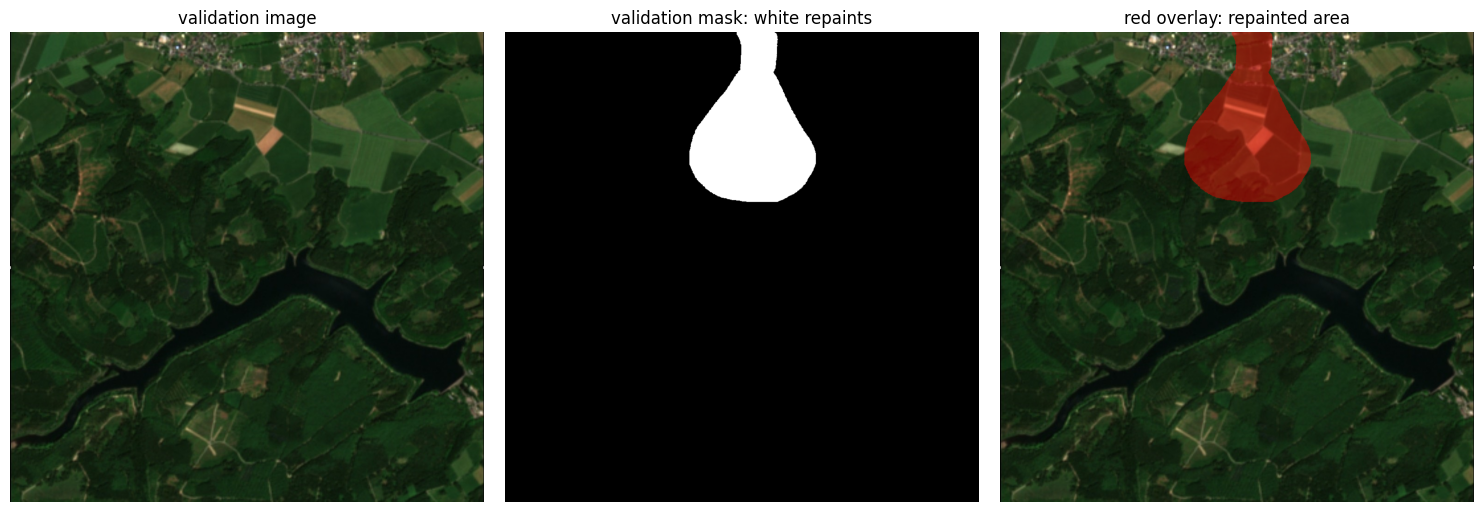

In [4]:
mask_array = np.asarray(sample_mask)
mask_coverage = float((mask_array > 0).mean())
print("mask coverage:", mask_coverage)

overlay = np.asarray(sample_image.convert("RGB")).copy()
overlay_mask = mask_array > 0
overlay[overlay_mask] = (
    0.55 * overlay[overlay_mask] + 0.45 * np.array([255, 0, 0])
).astype(np.uint8)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(sample_image)
axes[0].set_title("validation image")
axes[0].axis("off")
axes[1].imshow(sample_mask, cmap="gray")
axes[1].set_title("validation mask: white repaints")
axes[1].axis("off")
axes[2].imshow(overlay)
axes[2].set_title("red overlay: repainted area")
axes[2].axis("off")
plt.tight_layout()

## LoRA Training Notes

This training cell freezes the base Stable Diffusion inpainting model and trains only small LoRA adapters on the UNet attention layers (`to_q`, `to_k`, `to_v`, `to_out.0`). The base model is not rewritten.

The mask-weighted loss makes the adapter focus on predicting noise in the white mask area. That helps the model learn the requested object class inside masks, but it does not remove the inpainting model's normal tendency to blend with surrounding context.


In [5]:
set_seed(SEED)

accelerator = Accelerator(
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    mixed_precision=MIXED_PRECISION,
    project_config=ProjectConfiguration(
        project_dir=str(OUTPUT_DIR), logging_dir=str(OUTPUT_DIR / "logs")
    ),
)

load_kwargs = {"local_files_only": LOCAL_FILES_ONLY}
model_load_kwargs = {**load_kwargs, "use_safetensors": False}
tokenizer = CLIPTokenizer.from_pretrained(
    MODEL_ID, subfolder="tokenizer", **load_kwargs
)
text_encoder = CLIPTextModel.from_pretrained(
    MODEL_ID, subfolder="text_encoder", **model_load_kwargs
)
vae = AutoencoderKL.from_pretrained(MODEL_ID, subfolder="vae", **model_load_kwargs)
unet = UNet2DConditionModel.from_pretrained(
    MODEL_ID, subfolder="unet", **model_load_kwargs
)
noise_scheduler = DDPMScheduler.from_pretrained(
    MODEL_ID, subfolder="scheduler", **load_kwargs
)

if int(unet.config.in_channels) != 9:
    raise RuntimeError(
        f"Expected inpainting UNet with 9 channels, got {unet.config.in_channels}"
    )

vae.requires_grad_(False)
text_encoder.requires_grad_(False)
unet.requires_grad_(False)
unet.add_adapter(
    LoraConfig(
        r=RANK,
        lora_alpha=LORA_ALPHA,
        init_lora_weights="gaussian",
        target_modules=["to_q", "to_k", "to_v", "to_out.0"],
    )
)
unet.enable_gradient_checkpointing()
cast_training_params(unet, dtype=torch.float32)

weight_dtype = torch.float16 if MIXED_PRECISION == "fp16" else torch.float32
vae.to(accelerator.device, dtype=weight_dtype)
text_encoder.to(accelerator.device, dtype=weight_dtype)

dataset = InpaintDataset(DATASET_DIR, tokenizer, RESOLUTION, INSTANCE_PROMPT)
dataloader = DataLoader(
    dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    collate_fn=lambda examples: collate_fn(examples, tokenizer),
)

trainable_params = [
    parameter for parameter in unet.parameters() if parameter.requires_grad
]
print("trainable params:", sum(parameter.numel() for parameter in trainable_params))
optimizer = torch.optim.AdamW(
    trainable_params, lr=LEARNING_RATE, betas=(0.9, 0.999), weight_decay=1e-2, eps=1e-8
)
lr_scheduler = get_scheduler(
    "constant",
    optimizer=optimizer,
    num_warmup_steps=0,
    num_training_steps=MAX_TRAIN_STEPS,
)

unet, optimizer, dataloader, lr_scheduler = accelerator.prepare(
    unet, optimizer, dataloader, lr_scheduler
)

global_step = 0
num_epochs = math.ceil(
    MAX_TRAIN_STEPS / max(1, math.ceil(len(dataloader) / GRADIENT_ACCUMULATION_STEPS))
)
for epoch in range(num_epochs):
    unet.train()
    running_loss = 0.0
    for step, batch in enumerate(dataloader):
        with accelerator.accumulate(unet):
            pixel_values = batch["pixel_values"].to(dtype=weight_dtype)
            masks = batch["masks"].to(dtype=weight_dtype)
            masked_images = batch["masked_images"].to(dtype=weight_dtype)
            input_ids = batch["input_ids"].to(accelerator.device)

            latents = (
                vae.encode(pixel_values).latent_dist.sample()
                * vae.config.scaling_factor
            )
            masked_latents = (
                vae.encode(masked_images).latent_dist.sample()
                * vae.config.scaling_factor
            )
            mask_latents = F.interpolate(masks, size=latents.shape[-2:])
            noise = torch.randn_like(latents)
            timesteps = torch.randint(
                0,
                noise_scheduler.config.num_train_timesteps,
                (latents.shape[0],),
                device=latents.device,
            ).long()
            noisy_latents = noise_scheduler.add_noise(latents, noise, timesteps)
            encoder_hidden_states = text_encoder(input_ids, return_dict=False)[0]
            model_input = torch.cat(
                [noisy_latents, mask_latents, masked_latents], dim=1
            )
            model_pred = unet(
                model_input,
                timesteps,
                encoder_hidden_states=encoder_hidden_states,
                return_dict=False,
            )[0]
            squared_error = (model_pred.float() - noise.float()).pow(2)
            loss_weights = torch.where(
                mask_latents > 0.5,
                torch.full_like(mask_latents, MASK_LOSS_WEIGHT),
                torch.full_like(mask_latents, BACKGROUND_LOSS_WEIGHT),
            )
            loss = (squared_error * loss_weights).sum() / (
                loss_weights.sum() * squared_error.shape[1]
            ).clamp(min=1.0)

            accelerator.backward(loss)
            if accelerator.sync_gradients:
                accelerator.clip_grad_norm_(trainable_params, 1.0)
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad(set_to_none=True)
            running_loss += loss.detach().item()

        if accelerator.sync_gradients:
            global_step += 1
            if global_step % 10 == 0:
                accelerator.print(
                    f"step {global_step}/{MAX_TRAIN_STEPS} loss={running_loss / max(1, step + 1):.4f}"
                )
            if global_step % CHECKPOINTING_STEPS == 0 and accelerator.is_main_process:
                save_lora(
                    accelerator.unwrap_model(unet),
                    OUTPUT_DIR / f"checkpoint-{global_step}",
                )
            if global_step >= MAX_TRAIN_STEPS:
                break
    if global_step >= MAX_TRAIN_STEPS:
        break

accelerator.wait_for_everyone()
if accelerator.is_main_process:
    save_lora(accelerator.unwrap_model(unet), OUTPUT_DIR)
    (OUTPUT_DIR / "training_args.json").write_text(
        json.dumps(
            {
                "model_id": MODEL_ID,
                "dataset_dir": str(DATASET_DIR),
                "training_prompt": INSTANCE_PROMPT,
                "validation_prompt": VALIDATION_PROMPT,
                "resolution": RESOLUTION,
                "max_train_steps": MAX_TRAIN_STEPS,
                "learning_rate": LEARNING_RATE,
                "rank": RANK,
                "lora_alpha": LORA_ALPHA,
                "mask_loss_weight": MASK_LOSS_WEIGHT,
                "background_loss_weight": BACKGROUND_LOSS_WEIGHT,
                "validation_lora_scale": VALIDATION_LORA_SCALE,
                "validation_strength": VALIDATION_STRENGTH,
                "validation_guidance_scale": VALIDATION_GUIDANCE_SCALE,
                "seed": SEED,
            },
            indent=2,
        ),
        encoding="utf-8",
    )
print("saved:", OUTPUT_DIR / "pytorch_lora_weights.safetensors")

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: stable-diffusion-v1-5/stable-diffusion-inpainting
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\neman\Documents\UVPython\inpainting\notebooks\.venv\Lib\site-packages\huggingface_hub\utils\_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


trainable params: 3188736
step 10/3000 loss=0.1539
step 20/3000 loss=0.1518
step 30/3000 loss=0.0954
step 40/3000 loss=0.0511
step 50/3000 loss=0.1170
step 60/3000 loss=0.1208
step 70/3000 loss=0.0644
step 80/3000 loss=0.1376
step 90/3000 loss=0.2456
step 100/3000 loss=0.1503
step 110/3000 loss=0.0925
step 120/3000 loss=0.0815
step 130/3000 loss=0.2877
step 140/3000 loss=0.1065
step 150/3000 loss=0.2623
step 160/3000 loss=0.0563
step 170/3000 loss=0.1234
step 180/3000 loss=0.0708
step 190/3000 loss=0.1652
step 200/3000 loss=0.0778
step 210/3000 loss=0.0949
step 220/3000 loss=0.1853
step 230/3000 loss=0.2844
step 240/3000 loss=0.1736
step 250/3000 loss=0.1977
step 260/3000 loss=0.1073
step 270/3000 loss=0.1936
step 280/3000 loss=0.1587
step 290/3000 loss=0.2237
step 300/3000 loss=0.1642
step 310/3000 loss=0.0962
step 320/3000 loss=0.0585
step 330/3000 loss=0.0282
step 340/3000 loss=0.1002
step 350/3000 loss=0.1474
step 360/3000 loss=0.0587
step 370/3000 loss=0.0712
step 380/3000 loss=0.

## Standard Validation Notes

This cell compares the base model against the same model with the LoRA adapter enabled. It is the quickest check for whether the adapter is changing generation at all.

Use this for coarse tuning of prompt, LoRA scale, strength, and guidance before trying more involved inference strategies.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: C:\Users\neman\.cache\huggingface\hub\models--stable-diffusion-v1-5--stable-diffusion-inpainting\snapshots\8a4288a76071f7280aedbdb3253bdb9e9d5d84bb\text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion_inpaint.StableDiffusionInpaintPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analy

  0%|          | 0/38 [00:00<?, ?it/s]

  0%|          | 0/38 [00:00<?, ?it/s]

base vs LoRA mean abs diff: 2.8427226543426514


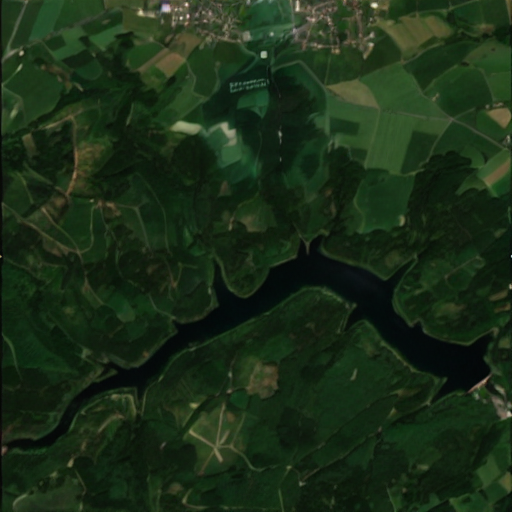

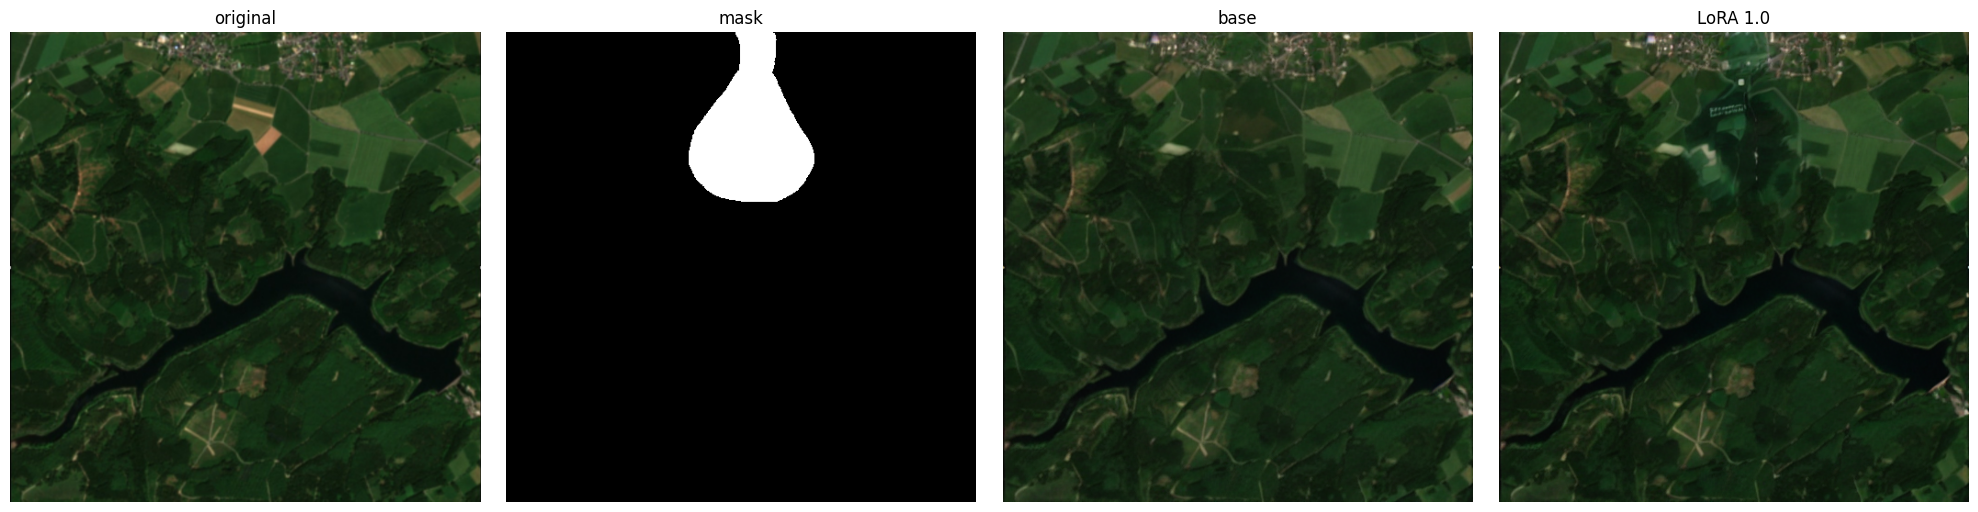

In [8]:
device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float16 if device == "cuda" else torch.float32
adapter_name = "sentinel_water"
pipe = StableDiffusionInpaintPipeline.from_pretrained(
    MODEL_ID,
    torch_dtype=dtype,
    safety_checker=None,
    local_files_only=LOCAL_FILES_ONLY,
    use_safetensors=False,
).to(device)
pipe.load_lora_weights(str(OUTPUT_DIR), adapter_name=adapter_name)
pipe.enable_lora()
pipe.set_progress_bar_config(disable=False)

test_image = sample_image.resize((RESOLUTION, RESOLUTION), Image.Resampling.BILINEAR)
test_mask = sample_mask.resize((RESOLUTION, RESOLUTION), Image.Resampling.NEAREST)


def run_validation(adapter_weight: float):
    # Reuse the same seed so the only intended difference is the LoRA adapter weight.
    pipe.enable_lora()
    pipe.set_adapters([adapter_name], adapter_weights=[adapter_weight])
    generator = torch.Generator(device=device).manual_seed(7)
    return pipe(
        prompt=VALIDATION_PROMPT,
        negative_prompt=NEGATIVE_PROMPT,
        image=test_image,
        mask_image=test_mask,
        height=RESOLUTION,
        width=RESOLUTION,
        strength=VALIDATION_STRENGTH,
        num_inference_steps=40,
        guidance_scale=VALIDATION_GUIDANCE_SCALE,
        generator=generator,
    ).images[0]


validation_base = run_validation(0.0)
validation = run_validation(VALIDATION_LORA_SCALE)
validation_base.save(OUTPUT_DIR / "validation_base.png")
validation.save(OUTPUT_DIR / "validation_lora.png")

diff = float(
    torch.as_tensor(
        np.asarray(validation_base, dtype=np.int16)
        - np.asarray(validation, dtype=np.int16)
    )
    .abs()
    .float()
    .mean()
)
print("base vs LoRA mean abs diff:", diff)
if diff == 0.0:
    raise RuntimeError(
        "LoRA validation is identical to base. Check that training finished and the adapter weights changed."
    )

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for axis, title, item, cmap in [
    (axes[0], "original", test_image, None),
    (axes[1], "mask", test_mask, "gray"),
    (axes[2], "base", validation_base, None),
    (axes[3], f"LoRA {VALIDATION_LORA_SCALE}", validation, None),
]:
    axis.imshow(item, cmap=cmap)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
validation

## Inference Trial Notes

These trials are inference-only mitigations; they do not change training weights.

The useful general controls are:

- `padding_mask_crop`: makes the inpainting pipeline focus on the masked area instead of the whole satellite image.
- mask dilation/blur: gives the model more or less room to redraw edges. Too much can look painted on top; too little can leave old terrain at the boundary.
- chunked bands: splits a large mask into smaller sequential inpaints. This is a general tactic and can also apply to roads, rivers, buildings, or other long shapes.
- lower LoRA scale / lower CFG: often reduces hallucinated center objects, but can also weaken the target concept.

For a street instead of a river, the same crop/chunking/mask-strength ideas can apply, but the prompts and negatives should be road-specific. The river-specific cleanup below should not be reused for streets.


running strong_crop_raw_no_blur


  0%|          | 0/57 [00:00<?, ?it/s]

running chunked_3_bands


  0%|          | 0/46 [00:00<?, ?it/s]

  0%|          | 0/46 [00:00<?, ?it/s]

...

running chunked_4_bands


  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

  0%|          | 0/45 [00:00<?, ?it/s]

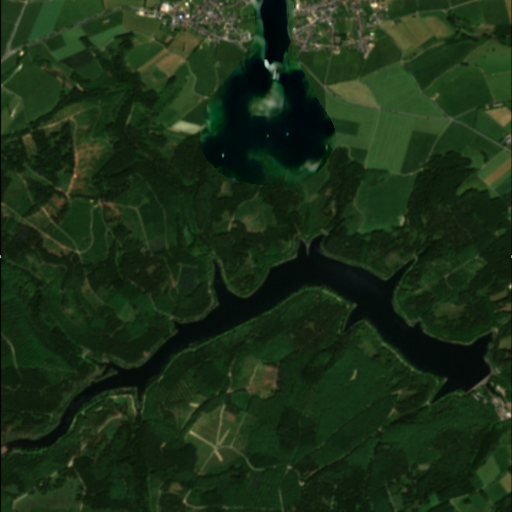

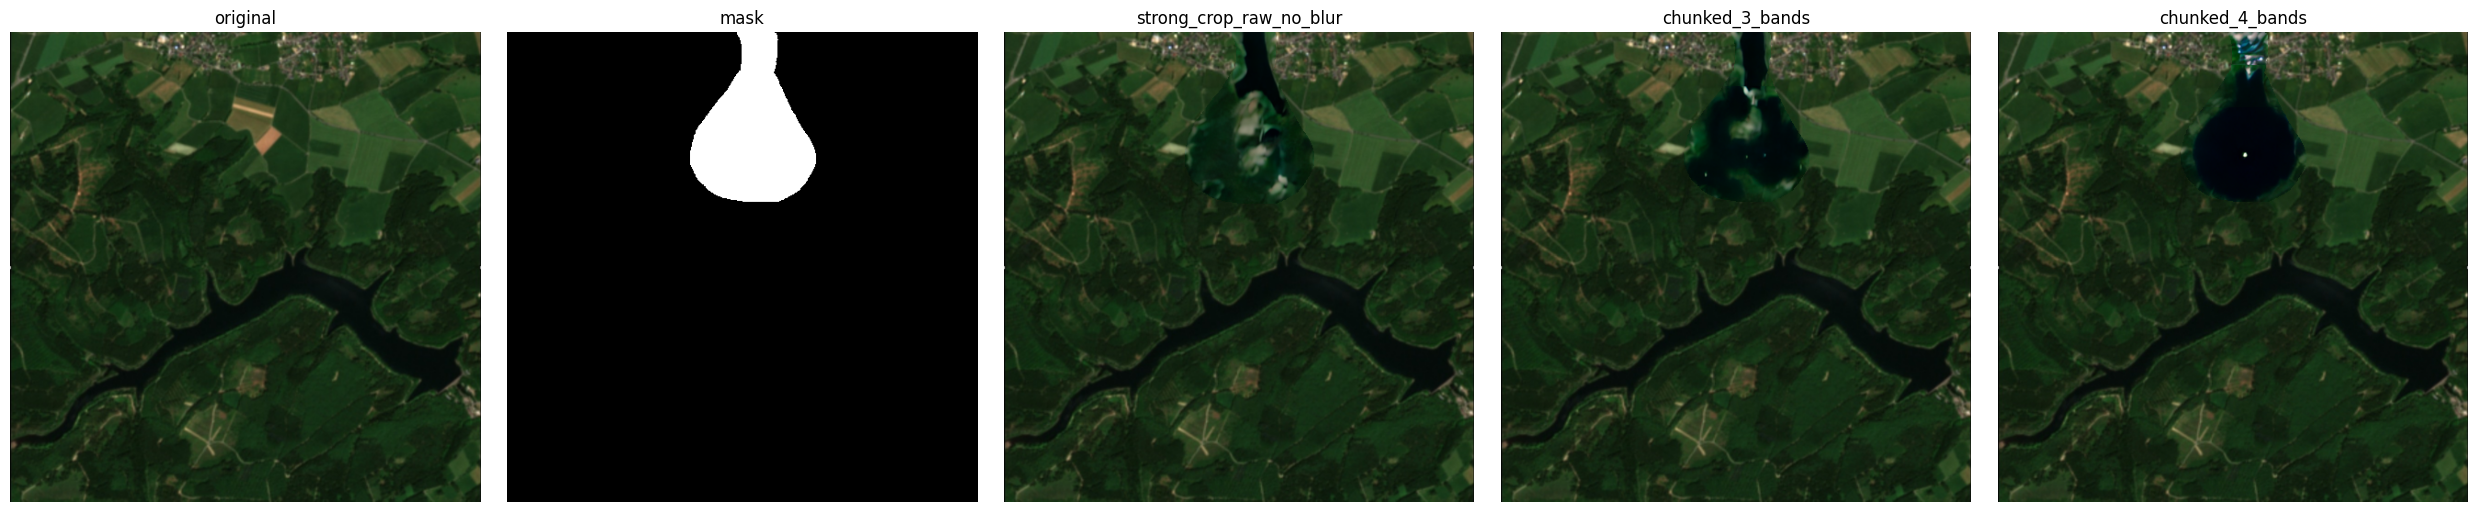

In [14]:
from PIL import ImageChops, ImageFilter

TRIAL_OUTPUT_DIR = OUTPUT_DIR / "validation_trials"
TRIAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def hard_mask(mask: Image.Image) -> Image.Image:
    return mask.convert("L").point(lambda value: 255 if value > 127 else 0)


def expand_mask(
    mask: Image.Image, dilation_px: int = 0, blur_px: float = 0.0
) -> Image.Image:
    trial_mask = hard_mask(mask)
    if dilation_px > 0:
        trial_mask = trial_mask.filter(ImageFilter.MaxFilter(dilation_px * 2 + 1))
    if blur_px > 0:
        trial_mask = trial_mask.filter(ImageFilter.GaussianBlur(blur_px))
    return trial_mask


def band_mask(
    mask: Image.Image, index: int, bands: int, overlap_px: int = 48
) -> Image.Image:
    base = hard_mask(mask)
    arr = np.asarray(base)
    ys, xs = np.where(arr > 0)
    if len(ys) == 0:
        raise ValueError("Validation mask is empty")

    min_y, max_y = int(ys.min()), int(ys.max()) + 1
    height = max_y - min_y
    band_start = min_y + int(index * height / bands)
    band_end = min_y + int((index + 1) * height / bands)
    band_start = max(min_y, band_start - overlap_px)
    band_end = min(max_y, band_end + overlap_px)

    band = np.zeros_like(arr, dtype=np.uint8)
    band[band_start:band_end, :] = 255
    band = np.where(arr > 0, band, 0).astype(np.uint8)
    return Image.fromarray(band, mode="L")


def shoreline_mask(
    mask: Image.Image,
    inner_erode_px: int = 2,
    outer_dilate_px: int = 8,
    blur_px: float = 2.0,
) -> Image.Image:
    base = hard_mask(mask)
    outer = base.filter(ImageFilter.MaxFilter(outer_dilate_px * 2 + 1))
    inner = base.filter(ImageFilter.MinFilter(inner_erode_px * 2 + 1))
    ring = ImageChops.subtract(outer, inner)
    if blur_px > 0:
        ring = ring.filter(ImageFilter.GaussianBlur(blur_px))
    return ring


def inpaint_once(
    name: str,
    *,
    image: Image.Image,
    mask: Image.Image,
    prompt: str,
    adapter_weight: float,
    guidance_scale: float,
    strength: float,
    num_inference_steps: int,
    seed: int,
    padding_mask_crop: int | None,
) -> Image.Image:
    pipe.enable_lora()
    pipe.set_adapters([adapter_name], adapter_weights=[adapter_weight])
    generator = torch.Generator(device=device).manual_seed(seed)
    result = pipe(
        prompt=prompt,
        negative_prompt=NEGATIVE_PROMPT,
        image=image,
        mask_image=mask,
        height=RESOLUTION,
        width=RESOLUTION,
        padding_mask_crop=padding_mask_crop,
        strength=strength,
        num_inference_steps=num_inference_steps,
        guidance_scale=guidance_scale,
        generator=generator,
    ).images[0]
    result.save(TRIAL_OUTPUT_DIR / f"{name}.png")
    mask.save(TRIAL_OUTPUT_DIR / f"{name}_mask.png")
    return result


def run_water_trial(
    name: str,
    *,
    prompt: str,
    adapter_weight: float,
    guidance_scale: float,
    strength: float,
    num_inference_steps: int = 60,
    seed: int = 11,
    dilation_px: int = 2,
    blur_px: float = 0.0,
    padding_mask_crop: int | None = 96,
    refine_edge: bool = False,
) -> Image.Image:
    inpaint_mask = expand_mask(test_mask, dilation_px=dilation_px, blur_px=blur_px)
    raw = inpaint_once(
        f"{name}_raw",
        image=test_image,
        mask=inpaint_mask,
        prompt=prompt,
        adapter_weight=adapter_weight,
        guidance_scale=guidance_scale,
        strength=strength,
        num_inference_steps=num_inference_steps,
        seed=seed,
        padding_mask_crop=padding_mask_crop,
    )

    if not refine_edge:
        raw.save(TRIAL_OUTPUT_DIR / f"{name}.png")
        return raw

    edge_mask = shoreline_mask(
        test_mask, inner_erode_px=2, outer_dilate_px=7, blur_px=2.0
    )
    refined = inpaint_once(
        f"{name}",
        image=raw,
        mask=edge_mask,
        prompt="satellite view of a natural river shoreline, shallow water edge, realistic terrain transition",
        adapter_weight=max(1.0, adapter_weight * 0.85),
        guidance_scale=5.5,
        strength=0.35,
        num_inference_steps=30,
        seed=seed + 1000,
        padding_mask_crop=padding_mask_crop,
    )
    edge_mask.save(TRIAL_OUTPUT_DIR / f"{name}_edge_refine_mask.png")
    return refined


def run_chunked_water_trial(
    name: str,
    *,
    prompt: str,
    adapter_weight: float,
    guidance_scale: float,
    strength: float,
    bands: int = 3,
    overlap_px: int = 56,
    num_inference_steps: int = 50,
    seed: int = 11,
    padding_mask_crop: int | None = 96,
) -> Image.Image:
    current = test_image
    for index in range(bands):
        mask = band_mask(test_mask, index=index, bands=bands, overlap_px=overlap_px)
        current = inpaint_once(
            f"{name}_band_{index + 1}",
            image=current,
            mask=mask,
            prompt=prompt,
            adapter_weight=adapter_weight,
            guidance_scale=guidance_scale,
            strength=strength,
            num_inference_steps=num_inference_steps,
            seed=seed + index * 37,
            padding_mask_crop=padding_mask_crop,
        )
    current.save(TRIAL_OUTPUT_DIR / f"{name}.png")
    return current


trial_prompt = (
    "flat calm uninterrupted river water seen from satellite, dark blue green water, "
    "continuous open water channel, realistic satellite imagery, no objects"
)

trials = [
    {
        "mode": "single",
        "name": "strong_crop_raw_no_blur",
        "prompt": trial_prompt,
        "adapter_weight": 1.55,
        "guidance_scale": 6.0,
        "strength": 0.95,
        "seed": 11,
        "dilation_px": 2,
        "blur_px": 0.0,
        "padding_mask_crop": 96,
        "refine_edge": False,
    },
    {
        "mode": "chunked",
        "name": "chunked_3_bands",
        "prompt": trial_prompt,
        "adapter_weight": 1.55,
        "guidance_scale": 6.0,
        "strength": 0.92,
        "bands": 3,
        "overlap_px": 64,
        "seed": 11,
        "padding_mask_crop": 96,
    },
    {
        "mode": "chunked",
        "name": "chunked_4_bands",
        "prompt": trial_prompt,
        "adapter_weight": 1.5,
        "guidance_scale": 5.75,
        "strength": 0.9,
        "bands": 4,
        "overlap_px": 56,
        "seed": 11,
        "padding_mask_crop": 96,
    },
]

trial_images = []
for trial in trials:
    mode = trial.pop("mode")
    print("running", trial["name"])
    if mode == "chunked":
        trial_images.append((trial["name"], run_chunked_water_trial(**trial)))
    else:
        trial_images.append((trial["name"], run_water_trial(**trial)))

fig, axes = plt.subplots(
    1, 2 + len(trial_images), figsize=(5 * (2 + len(trial_images)), 5)
)
for axis, title, item, cmap in [
    (axes[0], "original", test_image, None),
    (axes[1], "mask", test_mask, "gray"),
]:
    axis.imshow(item, cmap=cmap)
    axis.set_title(title)
    axis.axis("off")

for axis, (name, item) in zip(axes[2:], trial_images):
    axis.imshow(item)
    axis.set_title(name)
    axis.axis("off")

plt.tight_layout()
trial_images[1][1]

## Optional Cleanup Notes

This is a diagnostic, river-specific cleanup pass. It detects bright/green land-like pixels inside the intended water mask and repaints only those pixels.

This is not a general inpainting-model solution. It would not automatically work for painting a street, because the artifact detector encodes assumptions about water color and land color. For a general workflow, prefer the inference-trial controls above or retrain with more varied examples and better captions.

Skip this cell when evaluating whether the LoRA/inpainting setup itself is good enough.


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|          | 0/7 [00:00<?, ?it/s]

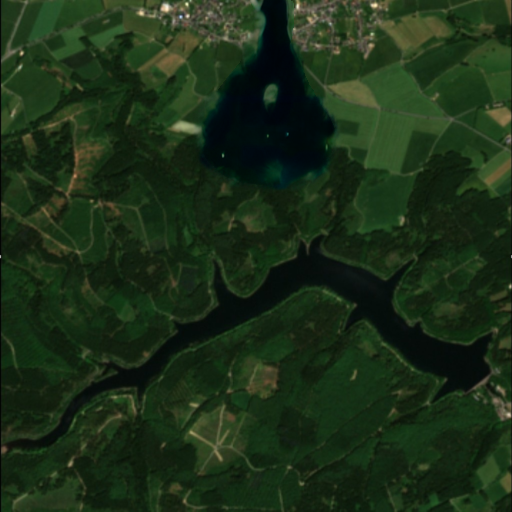

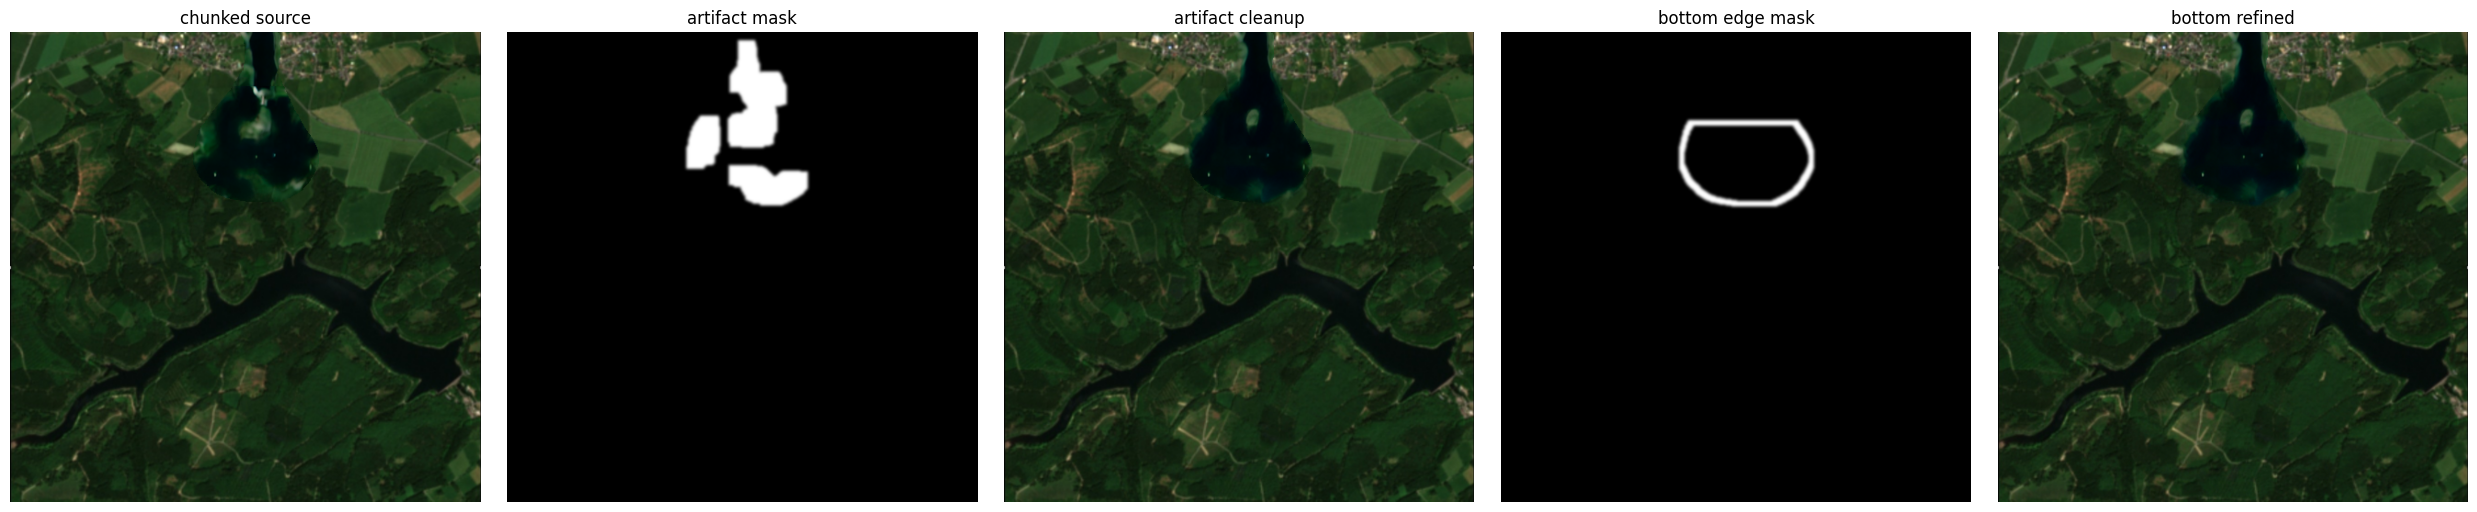

In [15]:
# Optional river-specific diagnostic cleanup: remove land-like artifacts inside generated water.

CLEANUP_SOURCE = TRIAL_OUTPUT_DIR / "chunked_3_bands.png"
if not CLEANUP_SOURCE.exists():
    raise FileNotFoundError(f"Run the chunked trials first; missing {CLEANUP_SOURCE}")


def landlike_artifact_mask(
    image: Image.Image,
    water_mask: Image.Image,
    min_area: int = 24,
    erode_px: int = 5,
    dilate_px: int = 9,
    blur_px: float = 1.5,
) -> Image.Image:
    image_array = np.asarray(image.convert("RGB")).astype(np.int16)
    mask = hard_mask(water_mask)
    if erode_px > 0:
        mask = mask.filter(ImageFilter.MinFilter(erode_px * 2 + 1))
    mask_array = np.asarray(mask) > 127

    red = image_array[..., 0]
    green = image_array[..., 1]
    blue = image_array[..., 2]
    brightness = red + green + blue

    land_like = mask_array & (
        ((green > blue + 18) & (green > 45))
        | ((red > blue + 22) & (green > blue + 10))
        | (brightness > 230)
    )

    components = label(land_like, connectivity=2)
    cleaned = np.zeros_like(land_like, dtype=np.uint8)
    for region in regionprops(components):
        if region.area >= min_area:
            cleaned[components == region.label] = 255

    artifact_mask = Image.fromarray(cleaned, mode="L")
    if dilate_px > 0:
        artifact_mask = artifact_mask.filter(ImageFilter.MaxFilter(dilate_px * 2 + 1))
    if blur_px > 0:
        artifact_mask = artifact_mask.filter(ImageFilter.GaussianBlur(blur_px))
    return artifact_mask


def lower_shoreline_mask(
    water_mask: Image.Image,
    start_fraction: float = 0.55,
    inner_erode_px: int = 1,
    outer_dilate_px: int = 5,
    blur_px: float = 1.5,
) -> Image.Image:
    base = hard_mask(water_mask)
    arr = np.asarray(base)
    ys, _ = np.where(arr > 0)
    if len(ys) == 0:
        raise ValueError("Validation mask is empty")
    min_y, max_y = int(ys.min()), int(ys.max()) + 1
    y_start = min_y + int((max_y - min_y) * start_fraction)

    lower = np.zeros_like(arr, dtype=np.uint8)
    lower[y_start:max_y, :] = 255
    lower = Image.fromarray(np.where(arr > 0, lower, 0).astype(np.uint8), mode="L")

    outer = lower.filter(ImageFilter.MaxFilter(outer_dilate_px * 2 + 1))
    inner = lower.filter(ImageFilter.MinFilter(inner_erode_px * 2 + 1))
    ring = ImageChops.subtract(outer, inner)
    if blur_px > 0:
        ring = ring.filter(ImageFilter.GaussianBlur(blur_px))
    return ring


source_image = Image.open(CLEANUP_SOURCE).convert("RGB")
artifact_mask = landlike_artifact_mask(source_image, test_mask)
artifact_mask.save(TRIAL_OUTPUT_DIR / "chunked_3_bands_artifact_cleanup_mask.png")

cleanup_prompt = (
    "flat calm uninterrupted dark blue green river water, open water only, "
    "continuous satellite water texture, no land, no island, no objects"
)

cleanup = inpaint_once(
    "chunked_3_bands_artifact_cleanup",
    image=source_image,
    mask=artifact_mask,
    prompt=cleanup_prompt,
    adapter_weight=1.35,
    guidance_scale=5.25,
    strength=0.75,
    num_inference_steps=40,
    seed=411,
    padding_mask_crop=96,
)

bottom_mask = lower_shoreline_mask(test_mask)
bottom_mask.save(TRIAL_OUTPUT_DIR / "chunked_3_bands_bottom_edge_mask.png")
cleanup_bottom = inpaint_once(
    "chunked_3_bands_artifact_cleanup_bottom_refine",
    image=cleanup,
    mask=bottom_mask,
    prompt="satellite view of a natural river edge, dark water meeting forest terrain, realistic shoreline transition",
    adapter_weight=1.1,
    guidance_scale=4.5,
    strength=0.28,
    num_inference_steps=25,
    seed=911,
    padding_mask_crop=96,
)

fig, axes = plt.subplots(1, 5, figsize=(25, 5))
for axis, title, item, cmap in [
    (axes[0], "chunked source", source_image, None),
    (axes[1], "artifact mask", artifact_mask, "gray"),
    (axes[2], "artifact cleanup", cleanup, None),
    (axes[3], "bottom edge mask", bottom_mask, "gray"),
    (axes[4], "bottom refined", cleanup_bottom, None),
]:
    axis.imshow(item, cmap=cmap)
    axis.set_title(title)
    axis.axis("off")
plt.tight_layout()
cleanup_bottom